# Example: Building a Maximum-Utility Portfolio Allocator
In this example, we build the allocator at the heart of the L7a rebalancing engine. We compute the two market inputs of the preference model from SPY, a market-state signal and a smoothed recent market growth rate, turn the single index model (SIM) parameters of thirteen firms into preference weights, read what the signs say about which firms belong in the basket on the first trading day of 2025 (nothing, as it turns out) and on the first day the basket is nonempty, solve the budget-constrained Cobb–Douglas allocation in closed form, check it against the course package, and compare the result with the CES allocations across the elasticity $\eta$ and with the minimum-variance and tangent portfolios of L6b.

> __Learning Objectives:__
>
> By the end of this example, you should be able to:
> * __Compute the market inputs of the preference model:__ Build the exponential moving averages of the SPY price and the crossover signal, and the smoothed recent market growth rate, from data available before the decision date, and read what they say about the market state.
> * __Select the basket and then allocate within it:__ Compute the preference weights from the SIM intercepts and betas and the market inputs, read the signs as the answer to which firms belong in the basket today, solve the Cobb–Douglas allocation among the preferred firms in closed form, and verify it against the package allocator.
> * __Compare allocators:__ Sweep the CES elasticity and read how it moves the allocation between concentration and equal share counts, and compare the utility allocations with the L6b minimum-variance and tangent portfolios.

Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include.jl")); # include the Include.jl file

  Activating project at `~/Desktop/julia_work/CHEME-5660-CourseRepository-Fall-2026`


The `Include.jl` file loads the course package [VLQuantitativeFinancePackage.jl](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/), together with [DataFrames.jl](https://dataframes.juliadata.org/stable/), [Statistics](https://docs.julialang.org/en/v1/stdlib/Statistics/), [LinearAlgebra](https://docs.julialang.org/en/v1/stdlib/LinearAlgebra/), [JLD2.jl](https://juliaio.github.io/JLD2.jl/stable/), [Plots.jl](https://docs.juliaplots.org/stable/), and [PrettyTables.jl](https://ronisbr.github.io/PrettyTables.jl/stable/). For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [CHEME 5660 Quantitative Finance Package documentation](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/).

### Data
We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period. This is the __training__ data: the SIM parameters in the archive were estimated from it, and every signal we compute below is calibrated on it. We also load the __testing__ data, calendar year 2025 (`01-02-2025` until `12-31-2025`), whose first trading day is the decision date of this example.

Let's load the training data by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet), keep only the firms with the maximum number of trading days (firms with fewer records were acquired or delisted during the period), and store the cleaned data in the `dataset::Dict{String,DataFrame}` variable:

In [2]:
dataset = let

    # initialize -
    original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"]; # training data, 2014 to 2024
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # AAPL has the maximum number of trading days
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Next, we do the same for the testing data by calling [the `MyTestingMarketDataSet()` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/data/#VLQuantitativeFinancePackage.MyTestingMarketDataSet), and store the cleaned 2025 data in the `dataset_2025::Dict{String,DataFrame}` variable:

In [3]:
dataset_2025 = let

    # initialize -
    original_dataset = MyTestingMarketDataSet() |> x-> x["dataset"]; # testing data, calendar year 2025
    maximum_number_trading_days = original_dataset["AAPL"] |> nrow;
    dataset = Dict{String, DataFrame}();

    # keep only the firms with the maximum number of trading days -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data;
        end
    end
    dataset; # return
end;

Finally, we load the single index model archive that the L6a estimation example saved, `SIMs-SP500-01-03-14-to-12-31-24.jld2`, [using the `JLD2.load(...)` function](https://juliaio.github.io/JLD2.jl/stable/). The archive holds, for every security fitted against SPY on the training data, the estimated intercept $\hat{\alpha}_{i}$ and beta $\hat{\beta}_{i}$ (fields `alpha`, `beta`), the residual growth-rate variance $s^{2}_{g,\varepsilon,i}$ (field `training_variance`, units: inverse years squared), the coefficient of determination (field `r_squared`), and their standard errors; and, once for the whole archive, the training-period sample mean $g^{\prime}_{M}$ and sample variance $s^{2}_{g,M}$ of the market growth rate (keys `market_mean` and `market_variance`). We check that the archive uses the growth-rate variance convention of the lecture and store the per-ticker parameters in the `sim_parameters::Dict{String,NamedTuple}` variable and the two market moments in the `g_market_mean::Float64` and `σ²_market::Float64` variables:

In [4]:
sim_parameters, g_market_mean, σ²_market = let
    archive = JLD2.load(joinpath(_PATH_TO_DATA, "SIMs-SP500-01-03-14-to-12-31-24.jld2"));
    @assert archive["variance_convention"] == "growth_rate" # residual variances are Var(ε) in (1/years)², as in the lecture
    println("SIM archive: $(length(archive["data"])) securities fitted against $(archive["market_ticker"]) on $(archive["date_range"][1][1:10]) to $(archive["date_range"][2][1:10]); growth definition: $(archive["growth_definition"])")
    (archive["data"], archive["market_mean"], archive["market_variance"]); # return
end;

SIM archive: 424 securities fitted against SPY on 2014-01-03 to 2024-12-31; growth definition: g_t = log(S_t/S_{t-1})/Δt with S the volume-weighted average price; units 1/years; no risk-free rate subtracted


### Constants
Finally, let's specify some constants that we will use in our analysis. Check out the comments for details on the constants, their permissible values, units, etc.

In [5]:
Δt = (1.0/252.0); # time step (1 trading day, in years)
W₀ = 1000.0; # initial wealth W_P(0) (units: USD)
g_f = 0.041; # risk-free growth rate (units: 1/years): continuously compounded equivalent of a one-year Treasury yield of about 4.16% at the end of 2024, as in L5b and L6b
L_short = 21; # short exponential moving average window (trading days)
L_long = 63; # long exponential moving average window (trading days)
L_growth = 10; # window of the exponential moving average of the daily market growth rate (trading days)
n_min = 0.01; # share floor for non-preferred assets (units: shares): a toehold of one hundredth of a share in every non-preferred firm
η_min = 0.5; # smallest CES elasticity used by the engine's rule η(ξ)
η_max = 5.0; # largest CES elasticity used by the engine's rule η(ξ)

___

## Task 1: Firms, SIM Parameters, and the Decision Date
We use the same $|\mathcal{P}| = 13$ firms as the L5b and L6b examples (technology, semiconductors, banks, automakers, and a health-care firm), stored in the `my_list_of_tickers::Array{String,1}` array:

In [6]:
my_list_of_tickers = ["AAPL", "MSFT", "INTC", "MU", "AMD", "NVDA", "GS", "BAC", "WFC", "C", "F", "GM", "JNJ"]; # |𝒫| = 13 firms, as in L5b and L6b

We pull the SIM intercepts $\hat{\alpha}_{i}$ (units: inverse years), betas $\hat{\beta}_{i}$ (dimensionless), residual variances $s^{2}_{g,\varepsilon,i}$ (units: inverse years squared), and coefficients of determination $R^{2}_{i}$ for our firms from the archive, and check that every firm has a positive beta, which the preference model below requires. We also assemble the SIM inputs of L6b, $\hat{\mathbf{g}}_{\text{SIM}} = \hat{\boldsymbol{\alpha}} + \hat{\boldsymbol{\beta}}\,g^{\prime}_{M}$ and $\hat{\mathbf{\Sigma}}_{g,\text{SIM}} = s^{2}_{g,M}\,\hat{\boldsymbol{\beta}}\hat{\boldsymbol{\beta}}^{\top} + \hat{\mathbf{D}}_{g}$, which we need in Task 4 to compute the minimum-variance and tangent portfolios. We store the results in the `α̂`, `β̂`, `s²_ε`, `R²`, `ĝ_sim`, and `Σ̂_g_sim` variables:

In [7]:
α̂, β̂, s²_ε, R², ĝ_sim, Σ̂_g_sim = let

    # SIM parameters for our firms -
    α̂ = [sim_parameters[ticker].alpha for ticker ∈ my_list_of_tickers]; # intercepts (units: 1/years)
    β̂ = [sim_parameters[ticker].beta for ticker ∈ my_list_of_tickers]; # betas (dimensionless)
    s²_ε = [sim_parameters[ticker].training_variance for ticker ∈ my_list_of_tickers]; # residual variances (units: 1/years²)
    R² = [sim_parameters[ticker].r_squared for ticker ∈ my_list_of_tickers]; # coefficients of determination
    @assert all(β̂ .> 0) # the preference model raises β to a real power, so every β must be positive

    # SIM inputs (L6b) -
    ĝ_sim = α̂ .+ β̂ .* g_market_mean; # SIM mean vector (units: 1/years)
    Σ̂_g_sim = σ²_market .* (β̂ * β̂') .+ Diagonal(s²_ε) |> Matrix; # rank one plus diagonal (units: 1/years²)

    (α̂, β̂, s²_ε, R², ĝ_sim, Σ̂_g_sim); # return
end;
println("β̂ ranges from $(round(minimum(β̂), digits=3)) to $(round(maximum(β̂), digits=3)); all positive")

β̂ ranges from 0.54 to 1.749; all positive


The decision date is the first trading day of 2025. Every quantity we compute below that describes the market state uses training data only, i.e., prices through the last trading day of 2024, so the decision is made with the information an investor had before that day's close. The engine of the lecture trades at the close (a market-on-close order fills at the closing price, which is known when the order fills), so the prices we allocate at are close prices. We store the decision-date close prices in the `S₀::Array{Float64,1}` variable:

In [8]:
S₀ = let
    for ticker ∈ vcat(my_list_of_tickers, "SPY")
        @assert dataset[ticker].timestamp == dataset["AAPL"].timestamp # aligned training dates
        @assert dataset_2025[ticker].timestamp == dataset_2025["AAPL"].timestamp # aligned 2025 dates
    end
    S₀ = [dataset_2025[ticker][1, :close] for ticker ∈ my_list_of_tickers]; # decision-date close prices (USD/share)
    println("decision date: $(Date(dataset_2025["AAPL"][1, :timestamp])); last training date: $(Date(dataset["AAPL"][end, :timestamp]))")
    S₀; # return
end;

decision date: 2025-01-02; last training date: 2024-12-31


___

## Task 2: The Market Inputs of the Preference Model
The preference model needs two numbers that describe the market on the decision date: a market-state signal $\xi_{t}$ built from the trend of the SPY price, and the recent market growth rate $\tilde{g}_{M,t}$ that plays the role of the SIM's expected market growth.

The signal is an exponential moving average (EMA) crossover of the SPY close price. For a price series $S_{t}$ and a window of $L$ days, the EMA is the recursion $\bar{S}_{t} = \omega\,S_{t} + (1-\omega)\,\bar{S}_{t-1}$ with $\omega = 2/(L+1)$. We compute a short EMA ($L_{\text{short}} = 21$ days) that tracks recent momentum and a long EMA ($L_{\text{long}} = 63$ days) that tracks the trend, and define the signal as the scaled crossover:
$$
\xi_{t} = -G\left(\frac{\bar{S}^{\text{short}}_{t}}{\bar{S}^{\text{long}}_{t}} - 1\right)
$$
where $G > 0$ is a dimensionless gain that sets the scale of the signal. The sign convention is that a __falling__ market (short EMA below the long EMA) gives $\xi_{t} > 0$, which the preference model reads as bearish, and a __rising__ market gives $\xi_{t} < 0$, bullish. We choose the gain on the training data so that $|\xi_{t}| \leq 1$ on 99% of training days: $G$ is the reciprocal of the 99th percentile of $|\bar{S}^{\text{short}}_{t}/\bar{S}^{\text{long}}_{t} - 1|$ after the warm-up period $t_{0} = L_{\text{short}} + L_{\text{long}}$.

The recent market growth rate $\tilde{g}_{M,t}$ is the EMA (window $L_{\text{growth}} = 10$ days) of the daily market growth rates $g_{M,t} = \ln(S_{t}/S_{t-1})/\Delta{t}$ of the SPY close series (units: inverse years; the archive's parameters were estimated on volume-weighted average prices, but as a market-state input the smoothed growth is computed from the same close series as the signal). Daily growth rates are annualized, so they are large numbers (their standard deviation is about $3$ per year) and even their 10-day average swings by about $\pm 1$ per year; that is a feature the model uses, not a defect: it is what lets the sign of a preference weight respond to the market. We store the training-period series in `ξ_train` and `g̃_M_train`, and the decision-date values, computed from the last training day, in `ξ` and `g̃_M`:

In [9]:
ξ_train, g̃_M_train, G, ξ, g̃_M = let

    # SPY close price over the training period and its two EMAs -
    spy_train = dataset["SPY"][:, :close];
    S̄_short = compute_ema(spy_train, L_short);
    S̄_long = compute_ema(spy_train, L_long);
    t₀ = L_short + L_long; # warm-up: EMAs are meaningful after this many days
    ratio = S̄_short ./ S̄_long .- 1.0; # crossover, dimensionless

    # gain: |ξ| ≤ 1 on 99% of training days after warm-up -
    G = 1.0/quantile(abs.(ratio[t₀:end]), 0.99);
    ξ_train = -G .* ratio;

    # recent market growth rate: EMA of the daily market growth rates (units: 1/years) -
    g_M = log.(spy_train[2:end] ./ spy_train[1:end-1]) ./ Δt; # daily market growth rates g_M,t from the close series (2766 values for 2767 prices)
    g̃_M_train = compute_ema(g_M, L_growth);

    (ξ_train, g̃_M_train, G, ξ_train[end], g̃_M_train[end]); # decision-date values are the last training-day values
end;
println("gain G = $(round(G, digits=2)); on the decision date ξ = $(round(ξ, digits=3)) and g̃_M = $(round(g̃_M, digits=3)) 1/yr (training-period mean g′_M = $(round(g_market_mean, digits=3)) 1/yr)")

gain G = 21.23; on the decision date ξ = -0.279 and g̃_M = -0.759 1/yr (training-period mean g′_M = 0.106 1/yr)


`Unhide` the code block below to see how we visualized the SPY price and its two EMAs over 2024 (top), the signal $\xi_{t}$ over the training period with the $\pm 1$ band the gain was chosen for (middle), and the smoothed market growth rate $\tilde{g}_{M,t}$ over 2024 with the training-period mean $g^{\prime}_{M}$ for scale (bottom).

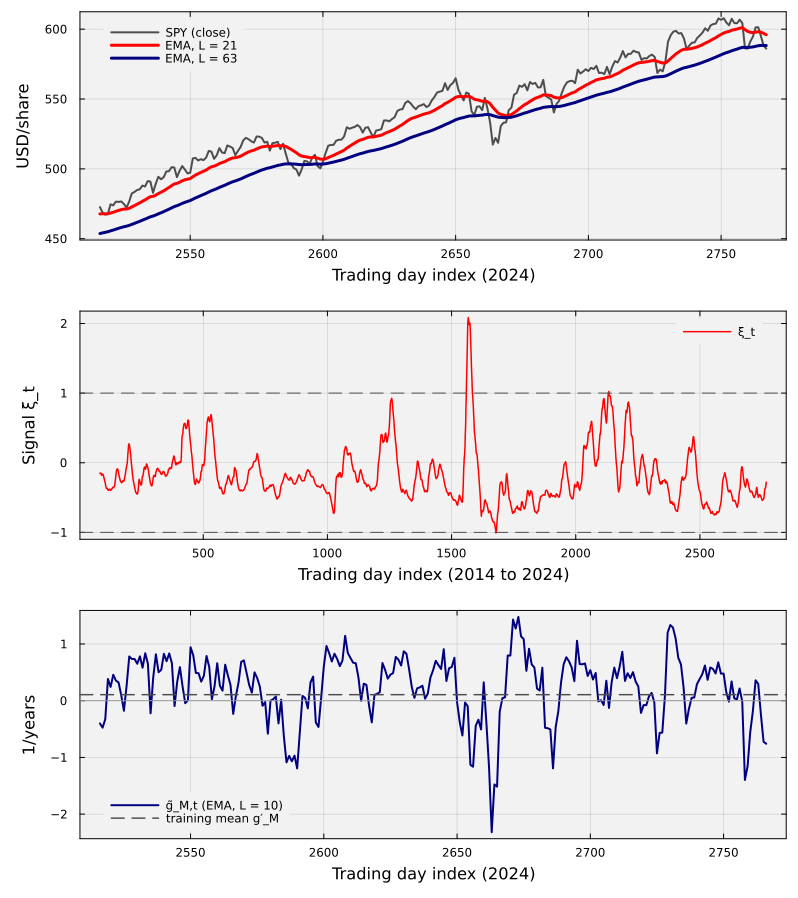

In [10]:
let
    spy_train = dataset["SPY"][:, :close];
    S̄_short = compute_ema(spy_train, L_short); S̄_long = compute_ema(spy_train, L_long);
    N = length(spy_train); window = (N-251):N; # calendar year 2024
    p1 = plot(window, spy_train[window], lw = 2, c = :gray30, label = "SPY (close)", ylabel = "USD/share")
    plot!(p1, window, S̄_short[window], lw = 3, c = :red, label = "EMA, L = $(L_short)")
    plot!(p1, window, S̄_long[window], lw = 3, c = :navy, label = "EMA, L = $(L_long)")
    plot!(p1, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft, xlabel = "Trading day index (2024)")
    t₀ = L_short + L_long;
    p2 = plot(t₀:N, ξ_train[t₀:N], lw = 1.5, c = :red, label = "ξ_t", ylabel = "Signal ξ_t")
    hline!(p2, [1.0, -1.0], lw = 1, ls = :dash, c = :gray30, label = "")
    plot!(p2, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, xlabel = "Trading day index (2014 to 2024)")
    gwindow = (length(g̃_M_train)-250):length(g̃_M_train); # 2024 (growth rates start one day after prices)
    p3 = plot(gwindow, g̃_M_train[gwindow], lw = 2, c = :navy, label = "g̃_M,t (EMA, L = $(L_growth))", ylabel = "1/years")
    hline!(p3, [g_market_mean], lw = 1.5, ls = :dash, c = :gray30, label = "training mean g′_M")
    hline!(p3, [0.0], lw = 1, c = :gray60, label = "")
    plot!(p3, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :bottomleft, xlabel = "Trading day index (2024)")
    plot(p1, p2, p3, layout = (3, 1), size = (800, 900), left_margin = 5Plots.mm)
end

___

## Task 3: Preference Weights, and Which Firms Belong in the Basket
The lecture's preference model maps the SIM parameters of each firm and the market inputs into a preference weight $\gamma_{i}(t)\in(-1,1)$:
$$
\gamma_{i}(t) = \tanh\left(\frac{\alpha_{i}}{\beta_{i}^{\xi_{t}}} + \beta_{i}^{1-\xi_{t}}\,\tilde{g}_{M,t}\right)
$$
The argument is the expected growth rate of firm $i$ under the SIM with the recent market growth in place of the training mean, $\alpha_{i} + \beta_{i}\tilde{g}_{M,t}$ (units: inverse years, read as a pure number at the one-year horizon), seen through a __regime lens__: the identity $\alpha_{i}/\beta_{i}^{\xi} + \beta_{i}^{1-\xi}\tilde{g}_{M} = (\alpha_{i} + \beta_{i}\tilde{g}_{M})/\beta_{i}^{\xi}$ shows that the signal divides that expectation by $\beta_{i}^{\xi_{t}}$. The model answers two coupled questions at once:

* __Which firms belong in the basket today?__ Because $\beta_{i}^{\xi_{t}} > 0$ and $\tanh$ preserves sign, the __sign__ of $\gamma_{i}(t)$ is the sign of $\alpha_{i} + \beta_{i}\tilde{g}_{M,t}$: a firm is preferred when its expected growth in the current market state is positive, i.e., when $\tilde{g}_{M,t} > -\alpha_{i}/\beta_{i}$. As the recent market growth moves, firms cross between the preferred and non-preferred sets: a strong market pulls in firms with negative $\alpha_{i}$ and large $\beta_{i}$, a weak market pushes out everything but the strongest intercepts. If __every__ $\gamma_{i}(t) \leq 0$, the model is saying that this basket is not the one to hold in these conditions: the allocator buys only the floor $n_{\min}$ of each firm and leaves the rest in cash, and an investor who is not content with cash should rethink which firms are in the basket (a question the course returns to with the ticker-picking methods of L12b and L13a).
* __How much of each preferred firm?__ The __magnitude__ of a positive $\gamma_{i}(t)$ sets the firm's share of the budget in the next task, and that is what the lens moves: a bearish signal ($\xi_{t} > 0$) divides by $\beta_{i}^{\xi_{t}} > 1$ for high-beta firms and by a number below one for low-beta firms, tilting the budget toward low-beta names, and a bullish signal does the reverse.

Let's compute the preference weights on the decision date and store them in the `γ₀::Array{Float64,1}` variable:

In [11]:
γ₀ = tanh.(α̂ ./ β̂ .^ ξ .+ β̂ .^ (1 - ξ) .* g̃_M); # preference weights on the decision date (first trading day of 2025)

let
    df = DataFrame(ticker = my_list_of_tickers, α̂ = round.(α̂, digits=4), β̂ = round.(β̂, digits=3), threshold = round.(-α̂ ./ β̂, digits=3),
        γ = round.(γ₀, digits=4), set = [g > 0 ? "preferred" : "non-preferred" for g ∈ γ₀]);
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("decision date: g̃_M = $(round(g̃_M, digits=3)) 1/yr; preferred set: {$(join(my_list_of_tickers[γ₀ .> 0], ", "))}; $(count(γ₀ .<= 0)) firms non-preferred, held at the floor n_min = $(n_min) shares")
end

 -------- --------- --------- ----------- --------- ---------------
  ticker         α̂         β̂   threshold         γ             set 
  String   Float64   Float64     Float64   Float64          String 
 -------- --------- --------- ----------- --------- ---------------
    AAPL    0.1061     1.195      -0.089   -0.6865   non-preferred
    MSFT    0.0999     1.152      -0.087   -0.6671   non-preferred
    INTC   -0.1484     1.184       0.125   -0.7997   non-preferred
      MU   -0.0532     1.695       0.031   -0.9142   non-preferred
     AMD    0.1275     1.739      -0.073   -0.8835   non-preferred
    NVDA    0.3468     1.749      -0.198   -0.8166   non-preferred
      GS   -0.0326      1.31       0.025    -0.803   non-preferred
     BAC   -0.0545     1.359        0.04   -0.8285   non-preferred
     WFC   -0.0914     1.238       0.074   -0.7985   non-preferred
       C   -0.1334     1.501       0.089   -0.8906   non-preferred
       F   -0.1928     1.434       0.134   -0.8888   non

On the first trading day of 2025 the recent market growth was strongly negative (SPY fell through late December 2024), below every firm's threshold $-\alpha_{i}/\beta_{i}$ (the `threshold` column), so __no firm is preferred__: the model says this basket does not belong in the market as it stood that morning, and the allocation would be the floor plus cash. To see how the classification and the lens move, let's compute the preferred set on each of the first sixty trading days of 2025 (each day's inputs use prices through the previous day, as the engine does), and record the first day $t_{\star}$ on which the preferred set is nonempty; we then use $t_{\star}$ as the allocation date for the rest of this example. We store the lagged 2025 inputs in `ξ_2025` and `g̃_M_2025`, and the allocation date and its inputs in `t_star`, `ξ_star`, `g̃_star`, `S_star`, and `γ`:

In [12]:
ξ_2025, g̃_M_2025, t_star, ξ_star, g̃_star, S_star, γ = let

    # joined SPY series (training then 2025) so the EMAs carry across the year boundary; then shift by one day -
    spy_train = dataset["SPY"][:, :close]; spy_2025 = dataset_2025["SPY"][:, :close];
    N_train = length(spy_train); N = length(spy_2025);
    spy_all = vcat(spy_train, spy_2025);
    S̄_short = compute_ema(spy_all, L_short); S̄_long = compute_ema(spy_all, L_long);
    ξ_all = -G .* (S̄_short ./ S̄_long .- 1.0);
    g_M_all = log.(spy_all[2:end] ./ spy_all[1:end-1]) ./ Δt; # daily market growth rates on the joined series (index k is the growth into price k+1)
    g̃_all = compute_ema(g_M_all, L_growth);
    ξ_2025 = [ξ_all[N_train + t - 1] for t ∈ 1:N]; # 2025 day t uses prices through day t-1
    g̃_M_2025 = [g̃_all[N_train + t - 2] for t ∈ 1:N]; # growth index shifted by one relative to prices
    @assert isapprox(ξ_2025[1], ξ; atol = 1e-12) && isapprox(g̃_M_2025[1], g̃_M; atol = 1e-12) # day 1 uses the last training day, as above

    # preferred set by day, and the first day it is nonempty -
    preferred_count = [count(α̂ .+ β̂ .* g̃_M_2025[t] .> 0) for t ∈ 1:N];
    t_star = findfirst(preferred_count .> 0);
    S_star = [dataset_2025[ticker][t_star, :close] for ticker ∈ my_list_of_tickers]; # close prices on the allocation date
    γ = tanh.(α̂ ./ β̂ .^ ξ_2025[t_star] .+ β̂ .^ (1 - ξ_2025[t_star]) .* g̃_M_2025[t_star]);

    df = DataFrame(day = 1:60, date = [Date(dataset_2025["AAPL"][t, :timestamp]) for t ∈ 1:60], ξ = round.(ξ_2025[1:60], digits=3), g̃_M = round.(g̃_M_2025[1:60], digits=3), preferred = preferred_count[1:60]);
    pretty_table(df[unique([1:5; max(1, t_star-2):t_star+2; 20:10:60]), :], backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("first day with a nonempty preferred set: t_star = $(t_star) ($(Date(dataset_2025["AAPL"][t_star, :timestamp]))): ξ = $(round(ξ_2025[t_star], digits=3)), g̃_M = $(round(g̃_M_2025[t_star], digits=3)) 1/yr, $(preferred_count[t_star]) preferred firms; over the first 60 days the preferred set was empty on $(count(preferred_count[1:60] .== 0)) days")

    (ξ_2025, g̃_M_2025, t_star, ξ_2025[t_star], g̃_M_2025[t_star], S_star, γ); # return
end;

 ------- ------------ --------- --------- -----------
    day         date         ξ       g̃_M   preferred 
  Int64         Date   Float64   Float64       Int64 
 ------- ------------ --------- --------- -----------
      1   2025-01-02    -0.279    -0.759           0
      2   2025-01-03    -0.246    -0.734           0
      3   2025-01-06    -0.232    -0.031           4
      4   2025-01-07    -0.226     0.238          13
      5   2025-01-08    -0.205    -0.326           0
     20   2025-01-31    -0.229      0.33          13
     30   2025-02-14     -0.24     0.496          13
     40   2025-03-03    -0.121    -0.324           0
     50   2025-03-17     0.351    -0.486           0
     60   2025-03-31     0.416    -1.046           0
 ------- ------------ --------- --------- -----------
first day with a nonempty preferred set: t_star = 3 (2025-01-06): ξ = -0.232, g̃_M = -0.031 1/yr, 4 preferred firms; over the first 60 days the preferred set was empty on 26 days


Here are the preference weights on the allocation date $t_{\star}$, and, to see what the lens does to the magnitudes, the same weights recomputed at fixed values of the signal $\xi \in \{-1, -0.5, 0, 0.5, 1\}$ with $\tilde{g}_{M}$ held at its $t_{\star}$ value. Watch two things: no firm changes sign as $\xi$ moves (the sign belongs to $\alpha_{i} + \beta_{i}\tilde{g}_{M}$), and the ranking among the preferred firms tilts toward high-beta names when the signal is bullish and toward low-beta names when it is bearish:

In [13]:
let
    df = DataFrame(ticker = my_list_of_tickers, β̂ = round.(β̂, digits=3), γ_at_t_star = round.(γ, digits=4), set = [g > 0 ? "preferred" : "non-preferred" for g ∈ γ]);
    for ξ_value ∈ [-1.0, -0.5, 0.0, 0.5, 1.0]
        df[!, "ξ = $(ξ_value)"] = round.(tanh.(α̂ ./ β̂ .^ ξ_value .+ β̂ .^ (1 - ξ_value) .* g̃_star), digits=4);
    end
    pretty_table(df, backend = :text, fit_table_in_display_horizontally = false, table_format = TextTableFormat(borders = text_table_borders__compact))
    println("allocation date t_star = $(t_star): preferred set {$(join(my_list_of_tickers[γ .> 0], ", "))}")
end

 -------- --------- ------------- --------------- ---------- ---------- --------- --------- ---------
  ticker         β̂   γ_at_t_star             set   ξ = -1.0   ξ = -0.5   ξ = 0.0   ξ = 0.5   ξ = 1.0 
  String   Float64       Float64          String    Float64    Float64   Float64   Float64   Float64 
 -------- --------- ------------- --------------- ---------- ---------- --------- --------- ---------
    AAPL     1.195        0.0719       preferred     0.0823     0.0754     0.069    0.0631    0.0578
    MSFT     1.152        0.0663       preferred     0.0739     0.0689    0.0642    0.0598    0.0557
    INTC     1.184       -0.1901   non-preferred    -0.2158    -0.1987    -0.183   -0.1685    -0.155
      MU     1.695       -0.1189   non-preferred    -0.1773    -0.1368   -0.1053    -0.081   -0.0623
     AMD     1.739        0.0835       preferred     0.1274     0.0968    0.0735    0.0558    0.0423
    NVDA     1.749        0.3213       preferred     0.4714     0.3688    0.2846    0.

___

## Task 4: The Cobb–Douglas Allocation
Given the preference weights on the allocation date, the Cobb–Douglas allocation problem chooses the share counts $n_{i}$ that maximize $U = \prod_{i\in\mathcal{A}^{+}} n_{i}^{\gamma_{i}}$ subject to the budget $\sum_{i}n_{i}S_{i}(t_{\star}) = W_{\mathcal{P}}(0)$, where $\mathcal{A}^{+} = \{i : \gamma_{i} > 0\}$ is the preferred set and $n_{i} > 0$ there; non-preferred firms are held exactly at the floor $n_{\min}$. With $W_{\text{adj}} = W_{\mathcal{P}}(0) - n_{\min}\sum_{k\in\mathcal{A}^{-}}S_{k}(t_{\star}) > 0$ the budget left after the floors, the closed-form solution of the lecture is:
$$
n_{i}^{\star} = \underbrace{\frac{\gamma_{i}}{\sum_{j\in\mathcal{A}^{+}}\gamma_{j}}}_{\text{preference share}}\cdot\underbrace{\frac{W_{\text{adj}}}{S_{i}(t_{\star})}}_{\text{budget in shares}}\qquad i\in\mathcal{A}^{+}
$$
so the __dollar__ weight of a preferred firm within the preferred budget is its normalized preference weight, $\gamma_{i}/\sum_{j\in\mathcal{A}^{+}}\gamma_{j}$, independent of prices; as a fraction of total wealth it is that number times $W_{\text{adj}}/W_{\mathcal{P}}(0)$, which is a little below one here because the floors take a few dollars. Let's compute the allocation by hand from this formula and check it against [the `allocate_cobb_douglas(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_cobb_douglas) of the course package, which solves the same problem. We store the package result in the `cd::NamedTuple` variable (fields `shares`, `dollars`, `weights`, `cash`) and the weights of total wealth in `w_CD`:

In [14]:
cd, w_CD = let

    # by hand: preferred and non-preferred sets, adjusted budget, closed form -
    A_plus = findall(γ .> 0); A_minus = findall(γ .<= 0);
    W_adj = W₀ - n_min*sum(S_star[A_minus]);
    @assert W_adj > 0
    n_hand = fill(n_min, length(γ));
    n_hand[A_plus] .= (γ[A_plus] ./ sum(γ[A_plus])) .* W_adj ./ S_star[A_plus];

    # package -
    cd = allocate_cobb_douglas(S_star, γ, W₀; epsilon = n_min);
    @assert isapprox(cd.shares, n_hand; atol = 1e-8) # same shares
    @assert isapprox(sum(cd.dollars) + cd.cash, W₀; atol = 1e-8) # budget spent
    @assert isapprox(cd.dollars[A_plus] ./ W_adj, γ[A_plus] ./ sum(γ[A_plus]); atol = 1e-10) # dollar weights within the preferred budget are normalized preferences

    (cd, cd.dollars ./ W₀); # weights of total wealth
end;
println("Cobb–Douglas on t_star: preferred budget W_adj = $(round(W₀ - n_min*sum(S_star[γ .<= 0]), digits=2)) USD, floors = $(round(n_min*sum(S_star[γ .<= 0]), digits=2)) USD, cash = $(round(cd.cash, digits=2)) USD; closed form matches the package")

Cobb–Douglas on t_star: preferred budget W_adj = 989.0 USD, floors = 11.0 USD, cash = 0.0 USD; closed form matches the package


How does the utility allocation compare with the portfolios of L6b built from the same SIM inputs? We compute the long-only global minimum-variance portfolio $\mathbf{w}_{\text{GMV}}$ from $(\hat{\mathbf{g}}_{\text{SIM}}, \hat{\mathbf{\Sigma}}_{g,\text{SIM}})$ [using the `MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem` type](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem) with the target set at the smallest expected growth rate (so the target does not bind), and the tangent portfolio $\mathbf{w}_{\mathcal{T}}$ by normalizing the risky weights of one solution of the risky and risk-free problem [(the `MyMarkowitzRiskyRiskFreePortfolioChoiceProblem` type)](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/portfolio/#VLQuantitativeFinancePackage.MyMarkowitzRiskyRiskFreePortfolioChoiceProblem), which L6b showed lie on one ray. We store them in `w_GMV` and `w_T`:

In [15]:
w_GMV, w_T = let
    number_of_assets = length(my_list_of_tickers);
    bounds = zeros(number_of_assets, 2); bounds[:,2] .= 1.0; # 0 ≤ wᵢ ≤ 1 on the risky weights
    initial = (1/number_of_assets)*ones(number_of_assets);

    # long-only GMV portfolio: risky-asset-only problem with a slack target -
    problem = build(MyMarkowitzRiskyAssetOnlyPortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, R = minimum(ĝ_sim)));
    w_GMV = solve(problem)["argmax"] |> w -> max.(w, 0.0) |> w -> w ./ sum(w); # clip solver noise of order 1e-9 below zero

    # tangent portfolio: normalize the risky weights of a risky and risk-free solution above g_f (ray property, L6b) -
    problem_rf = build(MyMarkowitzRiskyRiskFreePortfolioChoiceProblem, (Σ = Σ̂_g_sim, μ = ĝ_sim, bounds = bounds, initial = initial, risk_free_rate = g_f, R = 0.30));
    w_risky = solve(problem_rf)["argmax"];
    @assert sum(w_risky) > 1e-2
    w_T = max.(w_risky, 0.0) |> w -> w ./ sum(w); # solver noise of order 1e-9 below zero clipped

    (w_GMV, w_T); # return
end;

let
    df = DataFrame(ticker = my_list_of_tickers, γ = round.(γ, digits=4), w_CD = round.(w_CD, digits=4) .+ 0.0, w_GMV = round.(w_GMV, digits=4) .+ 0.0, w_T = round.(w_T, digits=4) .+ 0.0);
    push!(df, (ticker = "sum", γ = NaN, w_CD = round(sum(w_CD), digits=4), w_GMV = round(sum(w_GMV), digits=4), w_T = round(sum(w_T), digits=4)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    for (name, w) ∈ [("Cobb–Douglas", w_CD), ("GMV", w_GMV), ("tangent", w_T)]
        g = ĝ_sim'*w; σ = sqrt(w'*Σ̂_g_sim*w);
        println("$(name): E[g] = $(round(g, digits=4)) 1/yr, σ_g = $(round(σ, digits=4)) 1/yr, SR (annualized) = $(round((g - g_f)/σ/sqrt(Δt), digits=3)), β_P = $(round(β̂'*w, digits=3)), max weight = $(round(maximum(w), digits=3))")
    end
end

 -------- --------- --------- --------- ---------
  ticker         γ      w_CD     w_GMV       w_T 
  String   Float64   Float64   Float64   Float64 
 -------- --------- --------- --------- ---------
    AAPL    0.0719    0.1309    0.0879    0.2027
    MSFT    0.0663    0.1208    0.1417    0.2203
    INTC   -0.1901    0.0002    0.0441       0.0
      MU   -0.1189     0.001       0.0       0.0
     AMD    0.0835    0.1521       0.0    0.0405
    NVDA    0.3213    0.5852       0.0    0.5364
      GS   -0.0777    0.0058    0.0316       0.0
     BAC   -0.1033    0.0005    0.0057       0.0
     WFC   -0.1355    0.0007    0.0455       0.0
       C   -0.1951    0.0007       0.0       0.0
       F   -0.2522    0.0001       0.0       0.0
      GM   -0.1885    0.0005       0.0       0.0
     JNJ   -0.0285    0.0014    0.6434       0.0
     sum       NaN       1.0       1.0       1.0
 -------- --------- --------- --------- ---------
Cobb–Douglas: E[g] = 0.4172 1/yr, σ_g = 4.5996 1/yr, SR (annuali

`Unhide` the code block below to see the three weight vectors side by side.

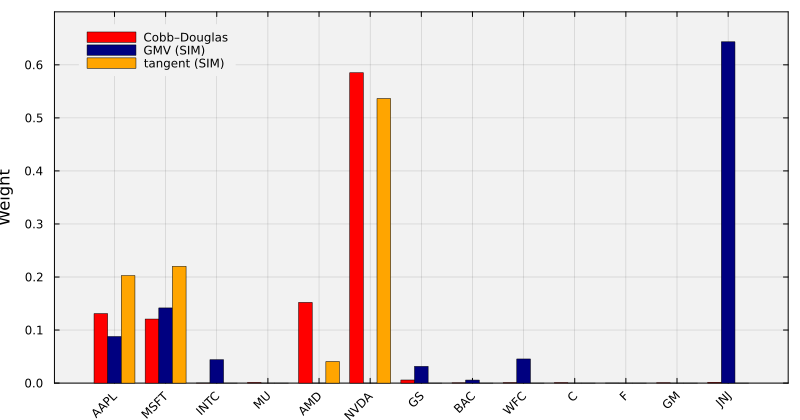

In [16]:
let
    number_of_assets = length(my_list_of_tickers);
    groupedbar(hcat(w_CD, w_GMV, w_T), bar_position = :dodge, bar_width = 0.8, lw = 0.5,
        c = [:red :navy :orange], label = ["Cobb–Douglas" "GMV (SIM)" "tangent (SIM)"],
        xticks = (1:number_of_assets, my_list_of_tickers), xrotation = 45, ylabel = "Weight", ylim = (0.0, 0.7),
        bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topleft, size = (800, 420))
end

___

## Task 5: CES Allocations and the Elasticity of Substitution
The CES utility $U_{\text{CES}} = \left(\sum_{i\in\mathcal{A}^{+}}\gamma_{i}\,n_{i}^{(\eta-1)/\eta}\right)^{\eta/(\eta-1)}$ generalizes Cobb–Douglas with an elasticity of substitution $\eta > 0$ that controls how willingly the allocator trades one preferred asset for another. Its budget-constrained solution is also closed form, $n_{i}^{\star} \propto (\gamma_{i}/S_{i}(t_{\star}))^{\eta}$ on the preferred set, and the lecture named its three limits: $\eta \to 1$ recovers Cobb–Douglas, $\eta \to \infty$ puts the whole budget on the firm with the largest $\gamma_{i}/S_{i}(t_{\star})$, and $\eta \to 0^{+}$ buys equal share counts of every preferred firm. Let's compute the CES allocation [using the `allocate_ces(...)` function](https://varnerlab.org/CHEME-5660-CourseRepository-Fall-2026/dev/adaptive/#VLQuantitativeFinancePackage.allocate_ces) for $\eta \in \{0.5, 1, 2, 5\}$ and for the engine's rule $\eta(\xi_{t}) = \eta_{\min} + (\eta_{\max} - \eta_{\min})/(1 + |\xi_{t}|)$ evaluated at the allocation-date signal $\xi_{t_{\star}}$, and check that $\eta = 1$ reproduces the Cobb–Douglas weights. For each allocation we report the largest weight and the effective number of holdings $1/\sum_{i}w_{i}^{2}$:

In [17]:
η_ξ = η_min + (η_max - η_min)/(1 + abs(ξ_star)); # the engine's elasticity rule at the allocation-date signal

let
    η_values = [0.5, 1.0, 2.0, 5.0, η_ξ];
    labels = ["η = 0.5", "η = 1", "η = 2", "η = 5", "η(ξ) = $(round(η_ξ, digits=2))"];
    df = DataFrame(ticker = my_list_of_tickers);
    summary = DataFrame(allocation = String[], max_weight = Float64[], effective_number = Float64[]);
    for (η, label) ∈ zip(η_values, labels)
        ces = allocate_ces(S_star, γ, W₀, η; epsilon = n_min);
        w = ces.dollars ./ W₀; # weights of total wealth
        df[!, label] = round.(w, digits=4) .+ 0.0;
        push!(summary, (allocation = label, max_weight = round(maximum(w), digits=4), effective_number = round(1/sum(w.^2), digits=3)));
        η == 1.0 && @assert isapprox(w, w_CD; atol = 1e-8) # η = 1 is Cobb–Douglas
    end
    push!(summary, (allocation = "Cobb–Douglas", max_weight = round(maximum(w_CD), digits=4), effective_number = round(1/sum(w_CD.^2), digits=3)));
    push!(summary, (allocation = "tangent (SIM)", max_weight = round(maximum(w_T), digits=4), effective_number = round(1/sum(w_T.^2), digits=3)));
    pretty_table(df, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
    pretty_table(summary, backend = :text, table_format = TextTableFormat(borders = text_table_borders__compact))
end

 -------- --------- --------- --------- --------- -------------
  ticker   η = 0.5     η = 1     η = 2     η = 5   η(ξ) = 4.15 
  String   Float64   Float64   Float64   Float64       Float64 
 -------- --------- --------- --------- --------- -------------
    AAPL    0.2102    0.1309    0.0269    0.0001        0.0004
    MSFT    0.2669    0.1208    0.0131       0.0        0.0001
    INTC    0.0002    0.0002    0.0002    0.0002        0.0002
      MU     0.001     0.001     0.001     0.001         0.001
     AMD    0.1648    0.1521    0.0686    0.0021        0.0057
    NVDA    0.3471    0.5852    0.8804    0.9868        0.9828
      GS    0.0058    0.0058    0.0058    0.0058        0.0058
     BAC    0.0005    0.0005    0.0005    0.0005        0.0005
     WFC    0.0007    0.0007    0.0007    0.0007        0.0007
       C    0.0007    0.0007    0.0007    0.0007        0.0007
       F    0.0001    0.0001    0.0001    0.0001        0.0001
      GM    0.0005    0.0005    0.0005    0.0005   

`Unhide` the code block below to see how the effective number of holdings and the largest weight change with $\eta$ over a fine grid, with the two Cobb–Douglas and $\eta(\xi_{t})$ values marked.

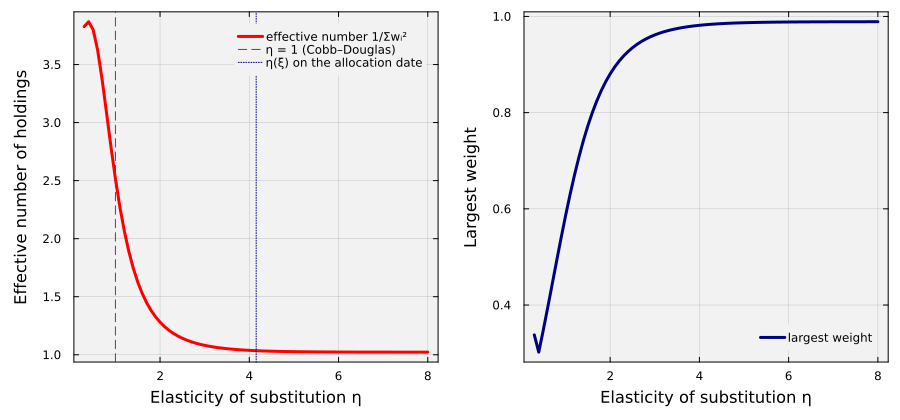

In [18]:
let
    η_grid = range(0.3, stop = 8.0, length = 78) |> collect;
    n_eff = [1/sum((allocate_ces(S_star, γ, W₀, η; epsilon = n_min).dollars ./ W₀).^2) for η ∈ η_grid];
    w_max = [maximum(allocate_ces(S_star, γ, W₀, η; epsilon = n_min).dollars ./ W₀) for η ∈ η_grid];
    p = plot(η_grid, n_eff, lw = 3, c = :red, label = "effective number 1/Σwᵢ²", ylabel = "Effective number of holdings", xlabel = "Elasticity of substitution η")
    vline!(p, [1.0], lw = 1, ls = :dash, c = :gray30, label = "η = 1 (Cobb–Douglas)")
    vline!(p, [η_ξ], lw = 1, ls = :dot, c = :navy, label = "η(ξ) on the allocation date")
    plot!(p, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :topright)
    p2 = plot(η_grid, w_max, lw = 3, c = :navy, label = "largest weight", ylabel = "Largest weight", xlabel = "Elasticity of substitution η")
    plot!(p2, bg = "gray95", background_color_outside = "white", framestyle = :box, fg_legend = :transparent, legend = :bottomright)
    plot(p, p2, layout = (1, 2), size = (900, 420), left_margin = 6Plots.mm, bottom_margin = 6Plots.mm)
end

___

## Summary
In this example, we built the maximum-utility allocator: the market-state signal and the recent market growth from SPY, preference weights from the SIM parameters of thirteen firms, the sign classification that decides which firms belong in the basket, and the Cobb–Douglas and CES allocations among the preferred firms, compared with the L6b minimum-variance and tangent portfolios.

> __Key Takeaways:__
>
> * __The market inputs set the sign and the lens:__ the recent market growth decides, firm by firm, whether the SIM expected growth in today's market is positive, and so which firms belong in the basket (on the first trading day of 2025, none of them, and the model said so); the EMA crossover signal then tilts the magnitudes toward low-beta names when bearish and toward high-beta names when bullish; both are computed from prices before the decision.
> * __Sign classifies, magnitude allocates, prices drop out:__ a non-positive preference weight sends a firm to the non-preferred set (held at the floor), and among the preferred firms the Cobb–Douglas dollar weights are the normalized preference weights, so the closed form needs no solver and matches the package allocator exactly.
> * __The elasticity sets concentration:__ CES with an elasticity of one is Cobb–Douglas; a larger elasticity concentrates the budget on the best bang for the buck, a smaller one spreads it toward equal share counts, and the engine's elasticity rule concentrates when the signal is quiet and diversifies when it is loud.

The next example wires this allocator into a daily loop with trigger rules and runs it through 2025, where the basket empties and refills as the market moves.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___